# MNIST MeanFlow Experiment Visualization

This notebook visualizes the results of a MeanFlow training experiment on MNIST.
It loads the training logs, plots loss curves, displays generated samples, and shows evaluation metrics (NLL/BPD).

In [1]:
# --- Configuration ---
# Set your experiment name here (folder name inside 'results/')
# EXP_NAME = "baseline_Dec_06-21_18_batch_size_32"  # batch_size=32
# EXP_NAME = "baseline_Dec_07-13_21_img_size_32"  # batch_size=32, gradient_accumulation_steps=4
# EXP_NAME = "baseline"
# EXP_NAME = "baseline_Dec_08-20_30_trained_on_AWS"
EXP_NAME = "half_baseline_half_ours_1_phase_Dec_08-20_36_first_attempt"
# EXP_NAME = "ours_1_phase_Dec_08-20_31_exploded"

# evaluation file name (default: evaluation_results.txt)
EVAL_NAME = "evaluation_results.txt"
# EVAL_NAME = "evaluation_results_100.txt"

import os
import subprocess
from vis_utils import plot_training_curves, show_eval_results, show_generated_samples

# Paths
exp_dir = os.path.join("results", EXP_NAME)
log_file = os.path.join(exp_dir, "log.txt")
images_dir = os.path.join(exp_dir, "images")
eval_results_file = os.path.join(exp_dir, EVAL_NAME)

print(f"Visualizing Experiment: {EXP_NAME}")
print(f"Directory: {exp_dir}")

Visualizing Experiment: half_baseline_half_ours_1_phase_Dec_08-20_36_first_attempt
Directory: results/half_baseline_half_ours_1_phase_Dec_08-20_36_first_attempt


## 1. Training Loss Curves

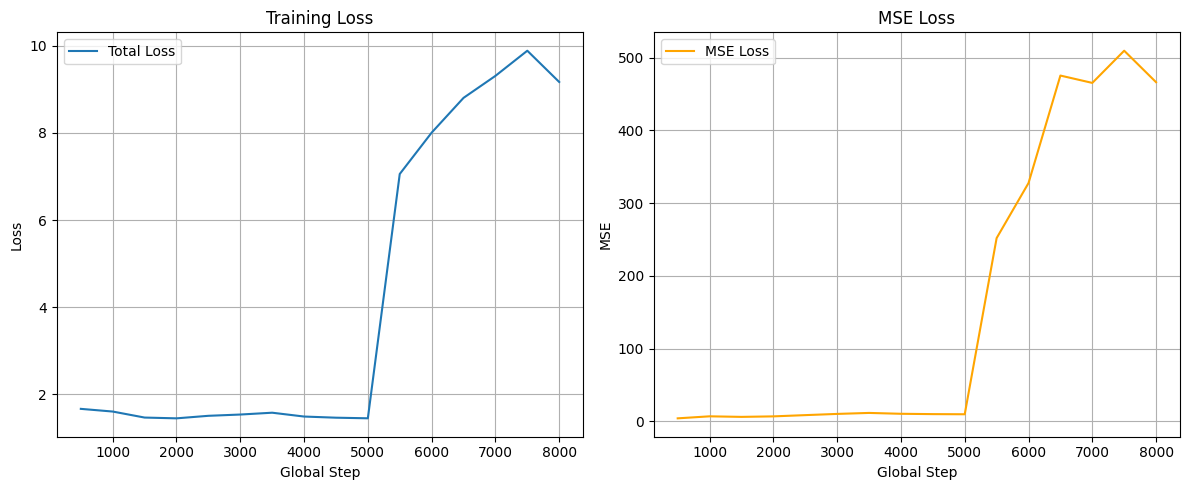

In [2]:
plot_training_curves(log_file)

## 2. Generated Samples

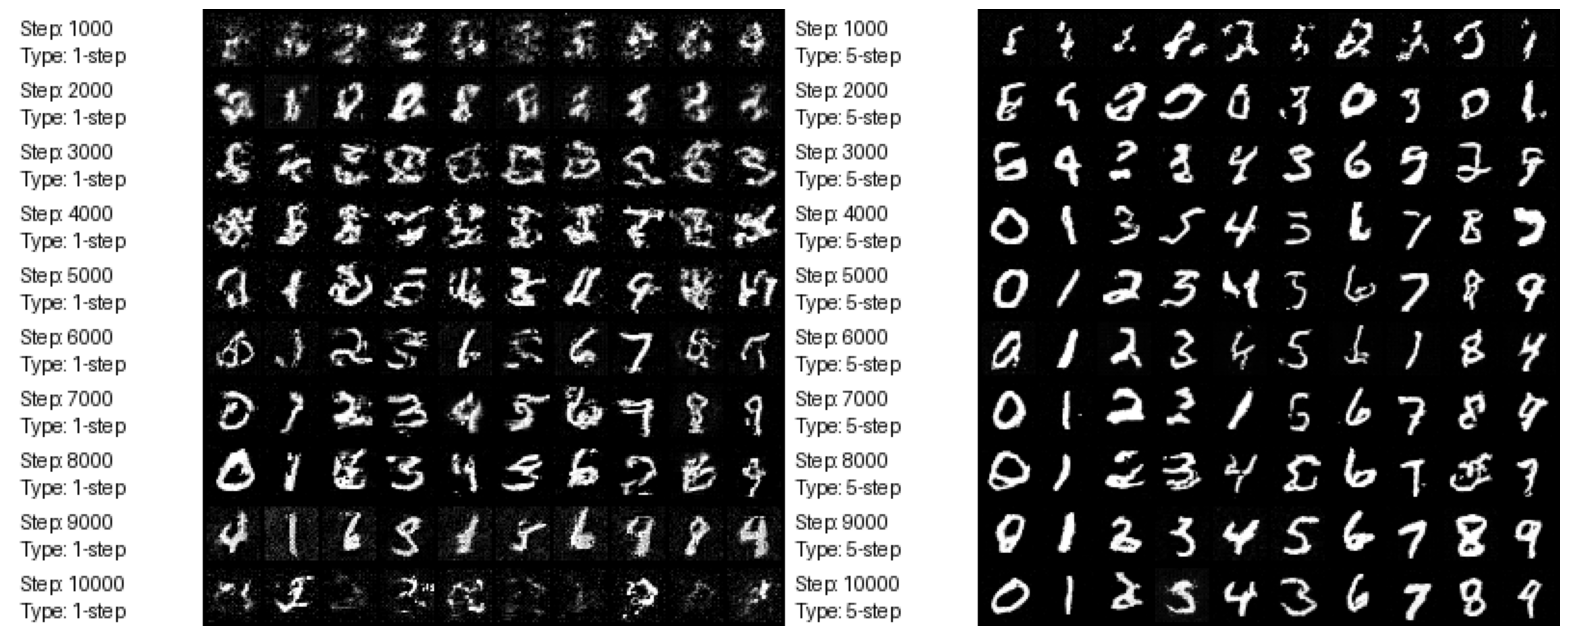

In [3]:
show_generated_samples(images_dir)

## 3. Evaluation Metrics (NLL & BPD)

BPD = 8 bit/dim: Just generating random noise. 
BPD < 4 bit/dim: Generating something good
BPD = 3 ~ 3.3 bit/dim: Baseline MeanFlow (?)
BPD = 1~2 bit/dim: state-of-the-art flow matching/diffusion

In [4]:
# Evaluate on only the last checkpoint
# show_eval_results(eval_results_file, EXP_NAME, limit_batches=1)

# Evaluate on a specific checkpoint
# show_eval_results(eval_results_file, EXP_NAME, ckpt_step=1000, limit_batches=1)

# Evaluate on ALL checkpoints (very expensive!)
show_eval_results(eval_results_file, EXP_NAME, show_all=True, limit_batches=1)

Evaluation results file not found: results/half_baseline_half_ours_1_phase_Dec_08-20_36_first_attempt/evaluation_results.txt
Running evaluation for experiment 'half_baseline_half_ours_1_phase_Dec_08-20_36_first_attempt'...
Using device: mps
Evaluating all checkpoints: [1000, 2000, 3000, 4000, 5000, 6000, 7000, 8000, 9000, 10000]


Traceback (most recent call last):
  File "/Users/huachun/CMU/haidog-MeanFlow/evaluate.py", line 74, in <module>
    model = MFDiT(
            ^^^^^^
  File "/Users/huachun/CMU/haidog-MeanFlow/models/dit.py", line 140, in __init__
    DiTBlock(dim, num_heads, mlp_ratio) for _ in range(depth)
    ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/huachun/CMU/haidog-MeanFlow/models/dit.py", line 76, in __init__
    self.mlp = Mlp(
               ^^^^
  File "/Users/huachun/CMU/haidog-MeanFlow/venv/lib/python3.12/site-packages/timm/layers/mlp.py", line 44, in __init__
    self.fc2 = linear_layer(hidden_features, out_features, bias=bias[1], **dd)
               ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/Users/huachun/CMU/haidog-MeanFlow/venv/lib/python3.12/site-packages/torch/nn/modules/linear.py", line 115, in __init__
    self.reset_parameters()
  File "/Users/huachun/CMU/haidog-MeanFlow/venv/lib/python3.12/site-packages/torch/nn/modules/linear.py", line 12

KeyboardInterrupt: 